In [ ]:
# Install libraries 
#install.packages("ggthemes") 
#install.packages("RColorBrewer") 
#install.packages("knitr")
#install.packages("DescTools") 
#install.packages("ggplot2") 
#install.packages("dplyr") 
#install.packages("scales")

# Load libraries 
library(dplyr) # Table manipulation 
library(ggplot2) # Data visualization
library(RColorBrewer) # Color palettes
library(ggthemes) # Additional themes for ggplot2
library(knitr) # Dynamic report generation (I like the kable output, less spacing issues)
library(DescTools) # Descriptive statistics
library(scales) # Scale functions for visualization

# Call in dataset
# https://www.kaggle.com/datasets/nelgiriyewithana/billionaires-statistics-dataset 
df <- read.csv("C:\\Users\\dimar\\Desktop\\TLS\\UCF\\Semester1\\Statistics\\Individual Project\\Billionaires Statistics Dataset.csv") 
head(df)

# Check the structure of the dataset
nrow(df)
ncol(df)
colnames(df)

# Objective
##### Learn about billionaire class structure
- Exploration
    - Richest billionaire from each industry, and how much they alone contribute to their industry's total billionaire worth.
    - Find out which industry contains the most, and the richest billionaires.
    - Top 10 richest individuals in dataset (2023)
    - Visualize wealth distributions
- Statistical Test
    - Test normalization of distributions within and across industries
    - Test if wealth distribution between industries differ significantly
    - Find which industries differ the most significantly within itself
    - Can any data predict the billionaires worth?
- Interpretation
    - I want to determine where wealth is concentrated in an industry. Equally, unequally? 

- Something to note. finalWorth is the networth, not their worth in that industry specifically. Elon Musk for example also owns SpaceX, which is not in the automotive industry.

In [ ]:
totals_df <- df %>%
  group_by(category) %>%
  summarise(
    total_worth = sum(totals_df$finalWorth),
    count = n()
  ) %>%
  arrange(desc(total_worth))

In [ ]:
totals_df <- as.data.frame(list(total_worth = as.numeric((df$finalWorth*1000)), category = df$category))
sub_tw_table <- data.frame(total_worth = totals_df$total_worth)

head(totals_df)
head(sub_tw_table)

,total_worth,category
,<dbl>,<chr>
1,2.11e+08,Fashion & Retail
2,1.80e+08,Automotive
3,1.14e+08,Technology
4,1.07e+08,Technology
5,1.06e+08,Finance & Investments
6,1.04e+08,Technology


,total_worth
,<dbl>
1,2.11e+08
2,1.80e+08
3,1.14e+08
4,1.07e+08
5,1.06e+08
6,1.04e+08


In [ ]:
# 1) Per-row numeric worth
df2 <- df %>%
  mutate(total_worth = as.numeric(finalWorth) * 1000)

# 2) Per-category frequency (count of rows)
freq_tbl <- df2 %>%
  count(category, name = "frequency")

# 3) Per-category total worth
totals_df <- df2 %>%
  group_by(category) %>%
  summarise(total = sum(total_worth), .groups = "drop") %>%
  arrange(desc(total)) %>%
  # 4) Join counts onto the per-category totals
  left_join(freq_tbl, by = "category") %>%
  # 5) Add a formatted label (keep numeric 'total' intact)
  mutate(total_worth = label_number(scale = 1e-9, accuracy = 0.01, suffix = "T")(total))

head(totals_df, 3)

category,total,frequency,total_worth
<chr>,<dbl>,<int>,<chr>
Technology,1877900000,314,1.88T
Fashion & Retail,1698800000,266,1.70T
Finance & Investments,1605100000,372,1.61T


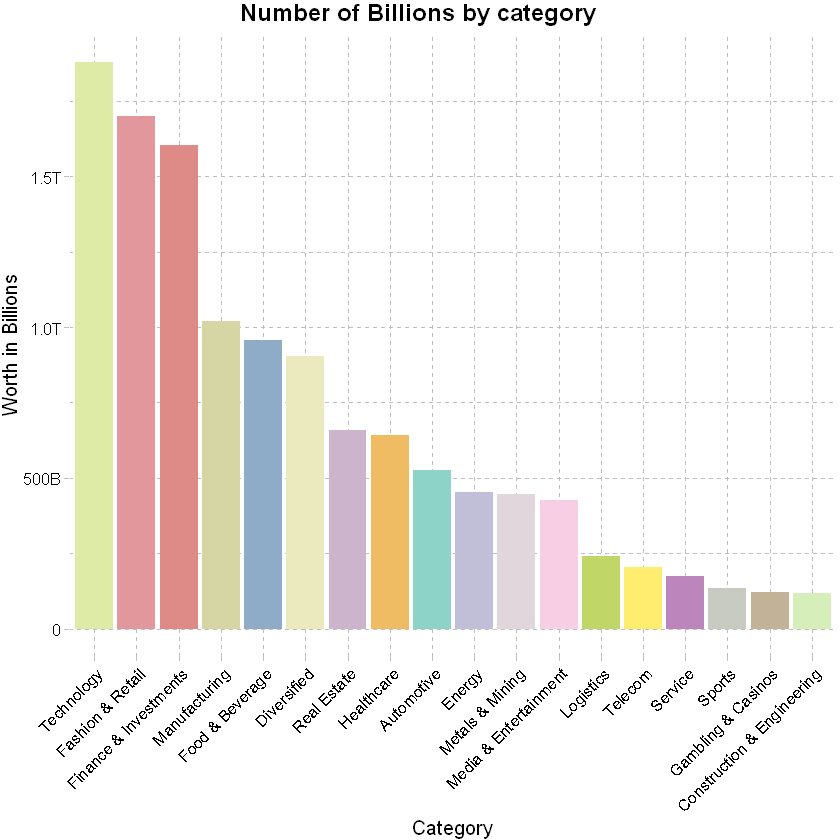

In [ ]:
# Some exploration
# Curious of which industries have the most billions of dollars

# Creates plot with df dataset. aes, aethestic mapping, x and y axis, what to fill by
ggplot(totals_df, aes(x = reorder(category, -total), y = total, fill = category)) +
  geom_bar(stat = "identity") + # Bar chart. Identity = bar height based on value in data for y.
  scale_fill_manual(
    values = colorRampPalette(brewer.pal(12, "Set3"))(length(unique(totals_df$category))) # Manual assignment of colors with a pallete to categories
  ) +
  scale_y_continuous(labels = scales::label_number(scale = 1e3, scale_cut = cut_short_scale())) + # Remove legend
  theme_pander() + # Theme from ggthemes
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.title.position = "plot"
    ) + # Adjust x-axis text angle and title position
    guides(fill = "none") +
  labs(
    title = "Number of Billions by category",
    x = "Category",
    y = "Worth in Billions")

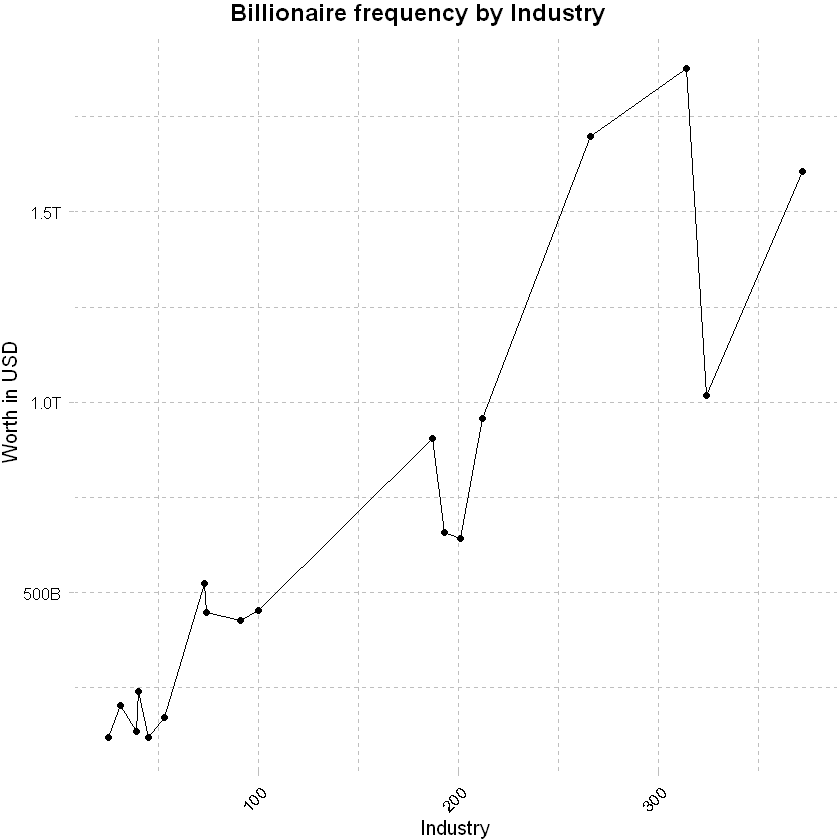

In [ ]:
# Scatter plot of total worth by county
ggplot(totals_df, aes(x = frequency, y = total)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  theme_pander() + # Theme from ggthemes
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.title.position = "plot"
    ) + # Adjust x-axis text angle and title position
  scale_y_continuous(labels = scales::label_number(scale = 1e3, scale_cut = cut_short_scale())) +
  guides(color = "none") +
  labs(
    title = "Billionaire frequency by Industry", 
    x = "Industry", 
    y = "Worth in USD")

#### Total worth of each industries billionaire networth
- Top 3 industries with most billionaire worth by a margin of ~0.6
    - Technology ~1.88T
    - Fashion & Retail ~1.70T
    - Finance & Investments ~1.61T

- The industries are not normally distributed visually.

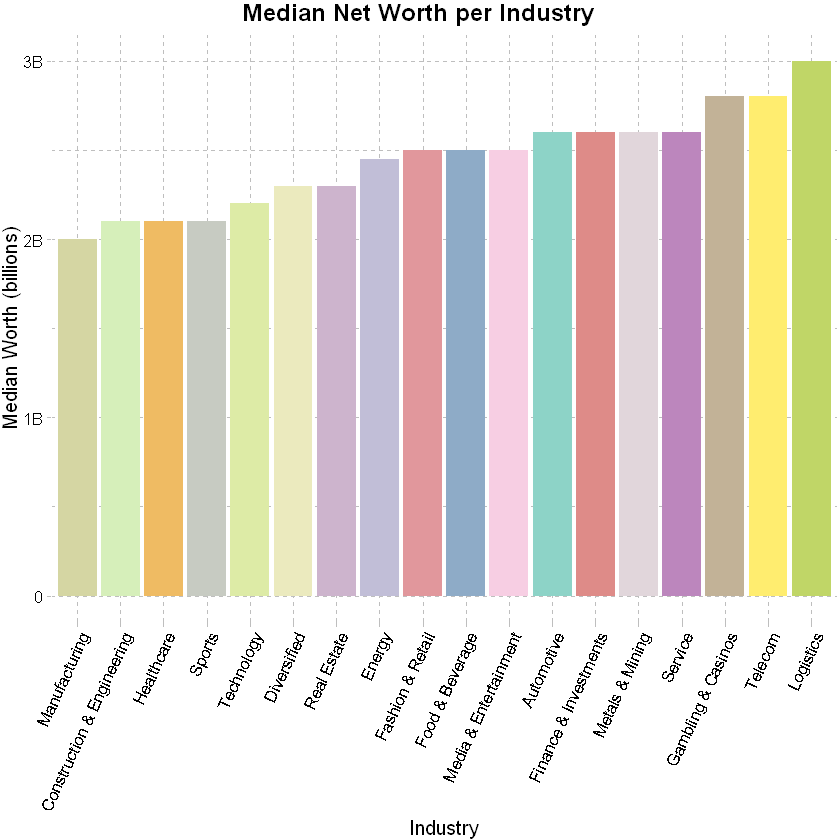

In [ ]:
ggplot(df %>% 
        group_by(category) %>% 
        summarise(medianWorth = median(finalWorth, na.rm = TRUE)),
       aes(x = reorder(category, medianWorth), y = medianWorth, fill = category)) +
  scale_fill_manual(
    values = colorRampPalette(brewer.pal(12, "Set3"))(length(unique(df$category))) # Manual assignment of colors with a pallete to categories
  ) +
  geom_col() +
  scale_y_continuous(labels = scales::label_number(scale = 1e6, scale_cut = cut_short_scale())) +
  theme_pander() +
    theme(
    axis.text.x = element_text(angle = 65, hjust = 1, vjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.title.position = "plot"
    ) +
  guides(fill = "none")  +
  labs(title = "Median Net Worth per Industry", x = "Industry", y = "Median Worth (billions)")

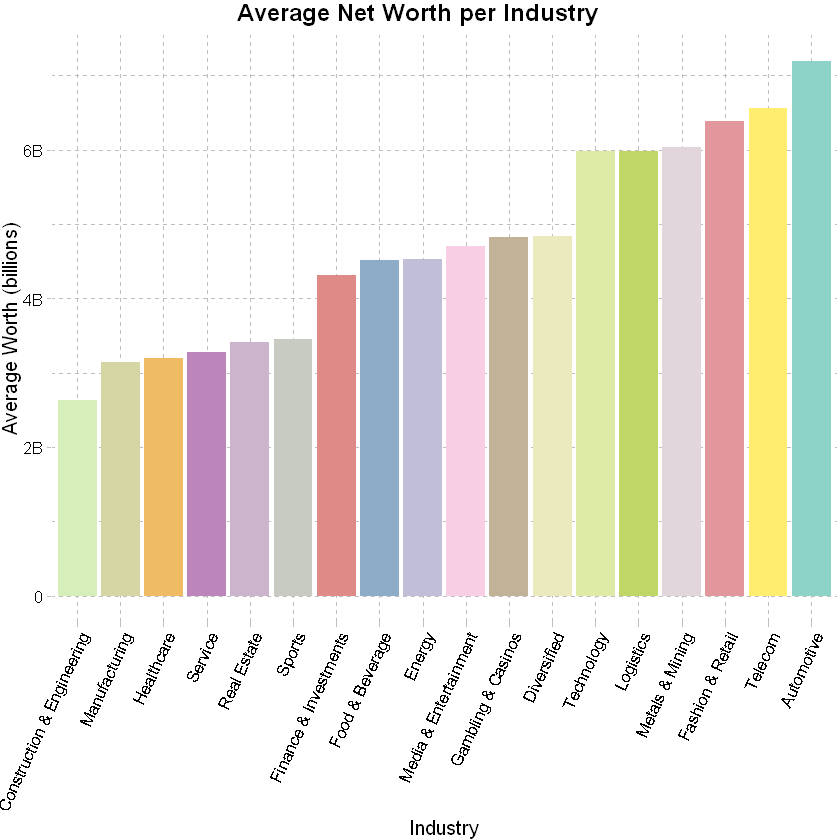

In [ ]:
ggplot(df %>% 
        group_by(category) %>% 
        summarise(meanWorth = mean(finalWorth, na.rm = TRUE)),
       aes(x = reorder(category, meanWorth), y = meanWorth, fill = category)) +
  scale_fill_manual(
    values = colorRampPalette(brewer.pal(12, "Set3"))(length(unique(df$category))) # Manual assignment of colors with a pallete to categories
  ) +
  geom_col() +
  scale_y_continuous(labels = scales::label_number(scale = 1e6, scale_cut = cut_short_scale())) +
  theme_pander() +
    theme(
    axis.text.x = element_text(angle = 65, hjust = 1, vjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.title.position = "plot"
    ) +
  guides(fill = "none")  +
  labs(title = "Average Net Worth per Industry", x = "Industry", y = "Average Worth (billions)")

# Quantity of billionaires, and billionaires worth by category, mean, median
- Quantity
    - Billionaire population is concentrated in a few dominant sectors
    - Finance & Investments, Manufacturing, Technology, Fashion & Retail, Food & Beverage, Healthcare > 200
- Worth by category
    - Naturally, industries with the most billionaires will accumulate more worth. 
    - Reflection of Quantity of billionaires.
- Average wealth
    - Some industries like Telecom or Automotive have fewer members
    - Among this, they still have their few extreme outliers
- Median wealth
    - Despite there being extreme outliers, and a disproportionate amount of billionaires, it seems the median wealth of a billionaire in any given category is between 2-3 billion, while the average is ~2-7.

- Interpretation
    - Billionaire representation is uneven across industries, yet typical wealth is quite consistent. There are extreme outliers I'd like to check an internal inequality on. 
    - A small number of billionaires hold vastly more wealth than their peers.

In [ ]:
# Dataset with the top 10 billionaires
# Already sorted by final worth
head(df[c(4,3,sum(df[2]*1000),6)], 10) %>% 
  kable()

ERROR: Error in `[.data.frame`(df, c(4, 3, sum(df[2] * 1000), 6)): undefined columns selected


In [ ]:
# Identify the top billionaire in each category
top_billionaires <- df %>%
  group_by(category) %>% # group by category
  slice_max(finalWorth, n = 1, with_ties = FALSE) %>% # get the top person in each category
  select(category, personName, finalWorth) %>% # select relevant columns
  arrange(desc(finalWorth))   # sorting

# Display the top billionaires in a table
top_billionaires %>%
  kable()



|category                   |personName                | finalWorth|
|:--------------------------|:-------------------------|----------:|
|Fashion & Retail           |Bernard Arnault & family  |     211000|
|Automotive                 |Elon Musk                 |     180000|
|Technology                 |Jeff Bezos                |     114000|
|Finance & Investments      |Warren Buffett            |     106000|
|Media & Entertainment      |Michael Bloomberg         |      94500|
|Telecom                    |Carlos Slim Helu & family |      93000|
|Diversified                |Mukesh Ambani             |      83400|
|Food & Beverage            |Zhong Shanshan            |      68000|
|Logistics                  |Klaus-Michael Kuehne      |      39100|
|Gambling & Casinos         |Miriam Adelson & family   |      35000|
|Manufacturing              |Reinhold Wuerth & family  |      29700|
|Real Estate                |Lee Shau Kee              |      29500|
|Metals & Mining            |Gin

In [ ]:
# Divide an individual rows finalWorth by the sum of each category.
# For each row, check if the category matches, then divide the finalWorth by the sum of finalWorth for that category.

df %>% # Get data
  group_by(category) %>% # group data by category
  summarise(total_worth = sum(finalWorth)) %>% # sum of finalWorth after grouping by category
  left_join(df, by = "category") %>% # Join with original df to get individual worth
  mutate(contribution = finalWorth / total_worth) %>% # Calculate contribution
  select(category, personName, finalWorth, contribution) %>% # Select relevant columns
  arrange(desc(contribution)) %>% # Sort by contribution high to low
  head(20) %>% # Display top 20
  kable() # Display as table; using package cause of spacing issue
  



|category                   |personName                | finalWorth| contribution|
|:--------------------------|:-------------------------|----------:|------------:|
|Telecom                    |Carlos Slim Helu & family |      93000|    0.4570025|
|Automotive                 |Elon Musk                 |     180000|    0.3426613|
|Gambling & Casinos         |Miriam Adelson & family   |      35000|    0.2904564|
|Media & Entertainment      |Michael Bloomberg         |      94500|    0.2210526|
|Logistics                  |Klaus-Michael Kuehne      |      39100|    0.1632568|
|Logistics                  |Gianluigi Aponte          |      31200|    0.1302714|
|Logistics                  |Rafaela Aponte-Diamant    |      31200|    0.1302714|
|Media & Entertainment      |David Thomson & family    |      54400|    0.1272515|
|Fashion & Retail           |Bernard Arnault & family  |     211000|    0.1242053|
|Service                    |Wang Wei                  |      21200|    0.1222607|
|C

# Measuring internal inequality
- High concentration
    - Telecom: Carlos Slim holds ~46% 
    - Automotive: Elon Musk holds ~34% 
    - Gambling & Casino: Miriam Adelson holds ~29%
    - Media & Entertainment: Michael Bloomberg holds ~22%
    - Logistics: Klaus, Gianluigi, and Rafaela hold ~ 38.7%

- Moderate concentration
    - Finance and Investments: Buffett holds ~6.6%
    - Diversified: Ambani holds ~9.2%
    - Technology: Jeff Bezos holds ~6.1%

- Highly concentrated wealth; Interpretation
    - With high percentages like these there is evidence of high inequality within industries.
    - Some industries have giants, or function like a one or few person empire. Like Telecom or Logistics.
    - Entire industries are quite 'top heavy'

- Moderately concentrated wealth; Interpretation
    - Industries with more billionaires have a better spread of wealth distribution

- Top individuals I can safely say is the range of 5-50%. Any industry with someone above 10-15% is very top heavy.

In [ ]:
# Create a new column for log of final worth
df$log_finalWorth <- log10(df$finalWorth + 1)

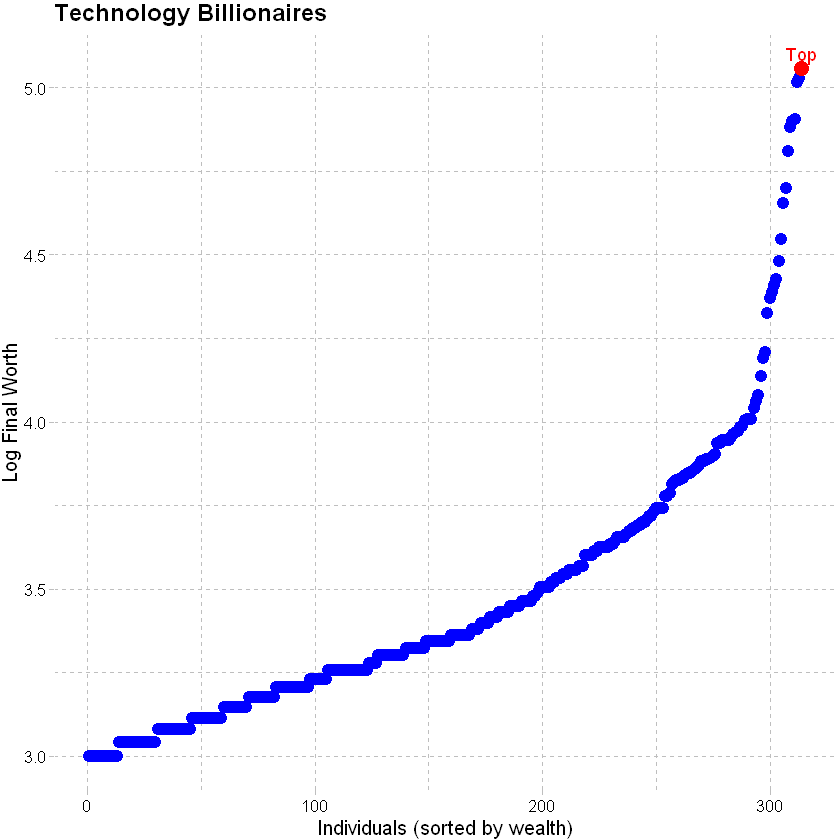

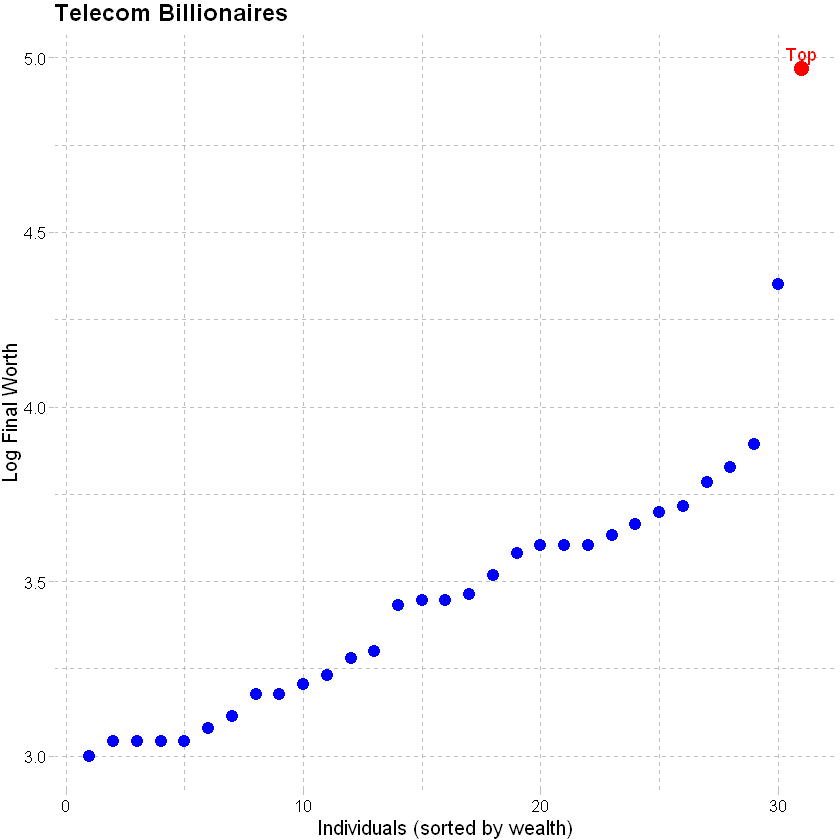

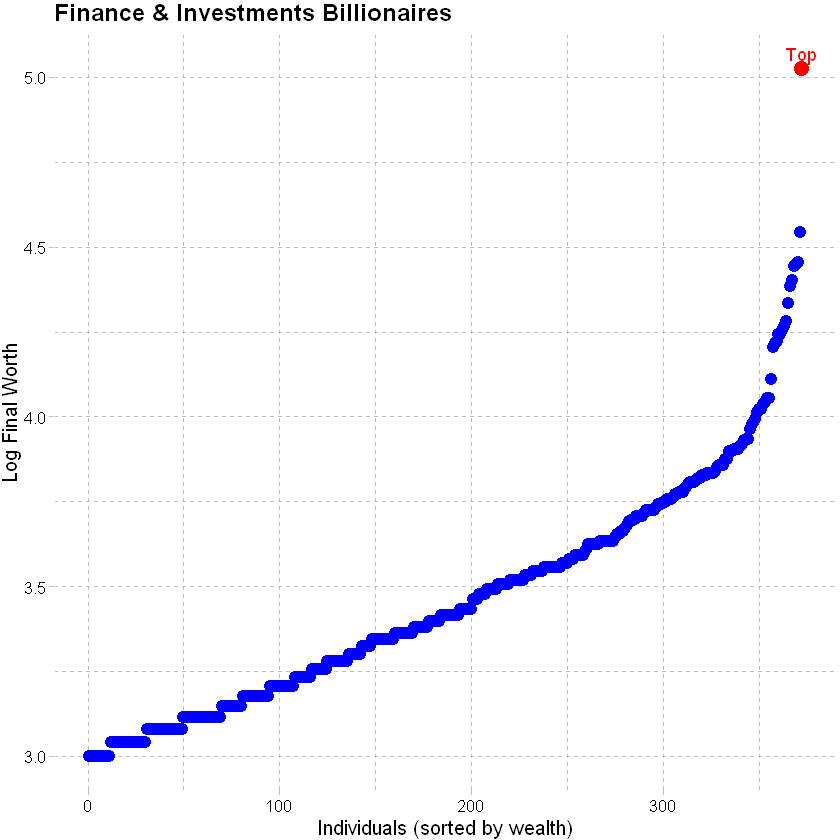

In [ ]:
# Function for one category
plot_category <- function(cat_name) { # Function for plot_category with category name as argument
  cat_df <- df %>%
    filter(category == cat_name) %>% # Filter for the category
    arrange(log_finalWorth) %>% # order by log_finalWorth
    mutate(idx = row_number()) # create index for x-axis

  lab_df <- cat_df %>%
    filter(log_finalWorth == max(log_finalWorth)) # Get the row with the max log_finalWorth for labeling

  ggplot(cat_df, aes(x = idx, y = log_finalWorth)) +
    geom_point(size = 3, color = "blue") +
    geom_point(data = lab_df, color = "red", size = 4) +
    geom_text(data = lab_df, aes(label = "Top"), vjust = -0.6, color = "red") +
    labs(title = paste(cat_name, "Billionaires"),
         x = "Individuals (sorted by wealth)",
         y = "Log Final Worth") + # Add labels
    theme_pander()
}

# Create plots
p1 <- plot_category("Technology")
p2 <- plot_category("Telecom")
p3 <- plot_category("Finance & Investments")

# Combine them side by side
p1 
p2
p3

## Observations
- Telecom:
    - Despite telecom being on the smaller end of total worth Carlos Slim Helu & Family, ranks at 8, holding a significant amount. The sharp rise of a tail shows an extreme concentration in a few, out of the already limited few (31 billionaires); resulting skewed distribution.

- Technology: 
    - The highest quantity of the wealthiest billionaires, clustered on the upper extreme. Hinting at multiple near-monopolies instead of one or dominant firms/organizations. Think Apple, AWS, Microsoft. While still having it's 314 billionaires throughout.

- Finance and investments:
    - Another densely populated right tail skew with a jump at the top to an individual. 

- Interpretion
    - This implies that billionaire wealth, despite that financial class being the wealthiest on the planet, is still dominated by a few from each industry. Thus, shaping the economic and power structure of their respective field.

- Note
    - Most of the wealthiest billionaires are in the United States (7/10)

- Everything till now has been data exploration and visualization.
- So first thing is to clean the data, remove na's, assure everything is formatted and standardized.

In [ ]:
# Getting na values in the dataset and counting them

# Get NAs, then sum up the true values 
cat("sum of NAs: ", sum(is.na(df)),"\n")

# Created a list of potential NA placeholders
na_placeholders = c("NA", "N/A", "", "Unknown","unknown", "null","NULL", "missing", "None")
# Counting the number of times they appear in the dataset
cat("sum of NA placeholders: ", sum(sapply(df, function(x) sum(as.character(x) %in% na_placeholders))),"\n")

# Replace NA placeholders with actual NA values
df <- as.data.frame(lapply(df, function(x) {
  x <- as.character(x)
  x[x %in% na_placeholders] <- NA
  type.convert(x, as.is = TRUE)
}))

# Check the number of NAs again
cat("sum of NAs after replacement: ", sum(is.na(df)),"\n")
cat("sum of NA placeholders after replacement: ", sum(sapply(df, function(x) sum(as.character(x) %in% na_placeholders))),"\n")

sum of NAs:  2063 
sum of NA placeholders:  8749 
sum of NAs after replacement:  10812 
sum of NA placeholders after replacement:  0 


In [ ]:
# This dropped to much data, so I'll reduce columns to only the ones I choose for my analysis

#nrow(df)
#sum(!complete.cases(df))  # number of rows that will be dropped
#df <- na.omit(df)
#sum(!complete.cases(df))  # 
#nrow(df)

In [ ]:
# Picking columns to keep
keep <- c("finalWorth","category", "gdp_country", 
            "population_country", "age", "gross_tertiary_education_enrollment", 
            "log_finalWorth")
sub_df <- df[,keep]
head(sub_df, 10)

,finalWorth,category,gdp_country,population_country,age,gross_tertiary_education_enrollment,log_finalWorth
,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,211000,Fashion & Retail,"$2,715,518,274,227",67059887,74,65.6,5.324285
2,180000,Automotive,"$21,427,700,000,000",328239523,51,88.2,5.255275
3,114000,Technology,"$21,427,700,000,000",328239523,59,88.2,5.056909
4,107000,Technology,"$21,427,700,000,000",328239523,78,88.2,5.029388
5,106000,Finance & Investments,"$21,427,700,000,000",328239523,92,88.2,5.025310
6,104000,Technology,"$21,427,700,000,000",328239523,67,88.2,5.017038
7,94500,Media & Entertainment,"$21,427,700,000,000",328239523,81,88.2,4.975436
8,93000,Telecom,"$1,258,286,717,125",126014024,83,40.2,4.968488
9,83400,Diversified,"$2,611,000,000,000",1366417754,65,28.1,4.921171


### Reasoning for chosen columns
- Firstly, to avoid dropping most of the dataset for NAs I am .
- finalWorth
    - My analysis is centered around this, how wealth is distributed, how it varies between industries, and to spot the extremes that influence distributions.
    - log_finalWorth is needed due to the scale.
- GDP and population
    - gdp_country is the size of the economy they are operating within
    - population_country is their immediate consumer base, granted most billionaire class are doing something global.
- Age
    - This captures generational timing with various world events and economic conditions.
    - Example being Wurth, the manufacturing giant. He came about post ww2 with a nail manufacturing organization. Right when the world needed to rebuild itself.
- Tertiary education
    - A countrys education shapes the landscape, since there are more highly qualified industries. As well as a social predictor for climbing into a new social group.

In [ ]:
cat("Number of rows before removing NA: ", nrow(sub_df), "\n")
cat("Number of rows with missing values: ", sum(!complete.cases(sub_df)), "\n")
sub_df <- na.omit(sub_df)
cat("Number of rows after removing NA: ", nrow(sub_df), "\n")

Number of rows before removing NA:  2640 
Number of rows with missing values:  231 
Number of rows after removing NA:  2409 


In [ ]:
# How many NAs were removed in each category, within sub_df
table(df$category) - table(sub_df$category)


                Automotive Construction & Engineering 
                         4                          4 
               Diversified                     Energy 
                        13                          7 
          Fashion & Retail      Finance & Investments 
                        22                         32 
           Food & Beverage         Gambling & Casinos 
                        21                          3 
                Healthcare                  Logistics 
                        10                          7 
             Manufacturing      Media & Entertainment 
                        34                          7 
           Metals & Mining                Real Estate 
                         3                         34 
                   Service                     Sports 
                         5                          1 
                Technology                    Telecom 
                        21                          3 

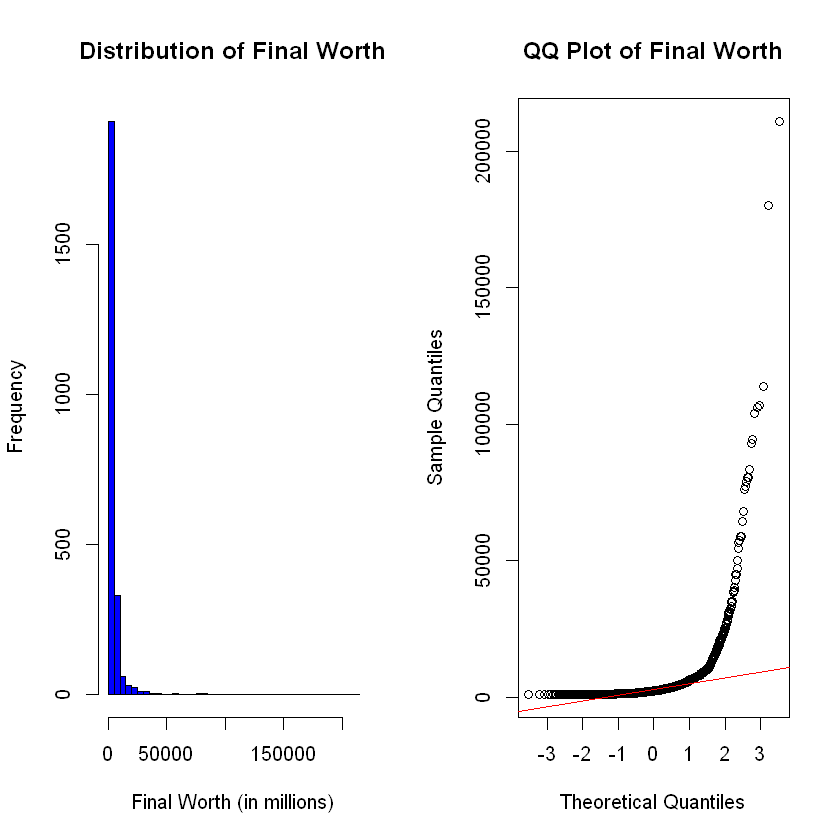

In [ ]:
# Check for normality
par(mfrow = c(1,2))
hist(sub_df$finalWorth, main = "Distribution of Final Worth", xlab = "Final Worth (in millions)", col = "blue", breaks = 30)
qqnorm(sub_df$finalWorth, main = "QQ Plot of Final Worth")
qqline(sub_df$finalWorth, col = "red")

##### Extreme right tail
- Going to use log here for a more normal distribution.

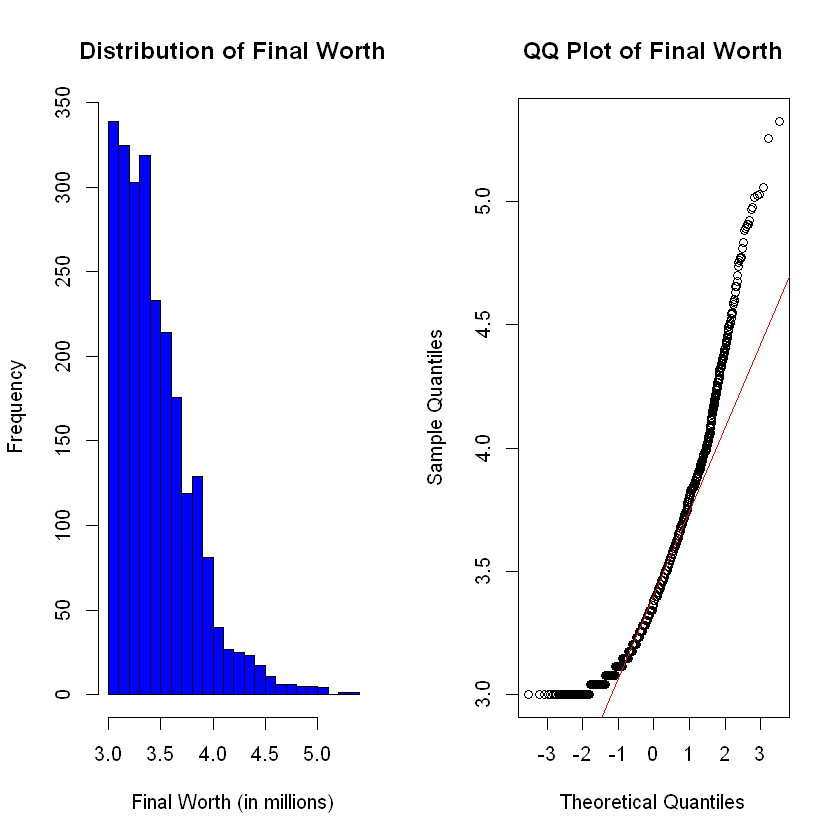

In [ ]:
# Check for normality again
par(mfrow = c(1,2))
hist(sub_df$log_finalWorth, main = "Distribution of Final Worth", xlab = "Final Worth (in millions)", col = "blue", breaks = 30)
qqnorm(sub_df$log_finalWorth, main = "QQ Plot of Final Worth")
qqline(sub_df$log_finalWorth, col = "red")

### Heavy right tail, not normal
- Improved normality from reducing the skewness with a log transformation
- Top billionaires cluster on the lower end of the wealth distributions tail.
- The taller spike on the left is the more typical billionaire worth.

In [ ]:
# null hypothesis: the distribution of log_finalWorth is normal
# alt hypothesis: the distribution of log_finalWorth is not normal

shapiro.test(sub_df$log_finalWorth)

by(sub_df$log_finalWorth, sub_df$category, shapiro.test)


	Shapiro-Wilk normality test

data:  sub_df$log_finalWorth
W = 0.90054, p-value < 2.2e-16


sub_df$category: Automotive

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.86756, p-value = 2.896e-06

------------------------------------------------------------ 
sub_df$category: Construction & Engineering

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.91741, p-value = 0.005644

------------------------------------------------------------ 
sub_df$category: Diversified

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.85183, p-value = 5.357e-12

------------------------------------------------------------ 
sub_df$category: Energy

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.93593, p-value = 0.0001948

------------------------------------------------------------ 
sub_df$category: Fashion & Retail

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.87805, p-value = 4.472e-13

------------------------------------------------------------ 
sub_df$category: Finance & Investments

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.93704, p-value = 8.104e-11

-------------

# W and p values
- Standalone 
    - finalWorth
        - W = 0.89984 p = 2.2e-16
- By category
    - Automotive
        - W = 0.86549  p = 2.147e-06
    - Construction & Engineering
        - W = 0.9175 p = 0.005023
    - Diversified
        - W = 0.85828 p = 5.253e-12
    - Energy
        - W = 0.84015 p = 0.0005952

- Interpretation
    - All categories have a p < 0.05; reject null hypothesis for all categories.
    - These results provide evidence that wealth distributions are not normal across or within industries
    - Using non-parametric methods like kruskal-wallis

In [ ]:
# Do wealth distributions differ by category?

# Null hypothesis: the distribution of log_finalWorth is the same across all categories
# Alternative hypothesis: the distribution of log_finalWorth differs across categories

kruskal.test(log_finalWorth ~ category, data = sub_df)


	Kruskal-Wallis rank sum test

data:  log_finalWorth by category
Kruskal-Wallis chi-squared = 39.606, df = 17, p-value = 0.001471


# Chi-squared, df, p-value
- Statistics
    - chi^2 = 39.74
    - df = 16
    - p-value = 0.001
- Interpretation
    - p < 0.05 rejects null, wealth distributions differ significantly across industries
    - At least a single categories distribution differs

In [ ]:
# Do any categories differ?
pairwise.wilcox.test(sub_df$log_finalWorth, sub_df$category, p.adjust.method = "BH", exact = FALSE )


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  sub_df$log_finalWorth and sub_df$category 

                           Automotive Construction & Engineering Diversified
Construction & Engineering 0.321      -                          -          
Diversified                0.630      0.527                      -          
Energy                     0.966      0.272                      0.527      
Fashion & Retail           0.983      0.158                      0.364      
Finance & Investments      0.988      0.151                      0.382      
Food & Beverage            0.994      0.167                      0.486      
Gambling & Casinos         0.963      0.564                      0.846      
Healthcare                 0.321      0.831                      0.560      
Logistics                  0.630      0.151                      0.346      
Manufacturing              0.298      0.846                      0.500      
Media & Entertainment

# Kruskal & wilcox
- With Kruskal-Wallis I'm asking if any categories differ.
- With Pairwise Wilcoxon I'm asking which categories differ. 

- Interpretation
    - Heterogeneity is clear, but none of the pairwise differences single any one out as significant.
- So far,
    - There is evidence for some distributional differences across industries, but they are small. However, no specific industry shows a significant difference. So they differ, slightly.

In [ ]:
gini_by_industry <- sub_df %>%
  group_by(category) %>%
  summarise(gini = Gini(finalWorth)) %>%
  arrange(desc(gini)) %>%
  as.data.frame()

gini_by_industry

category,gini
<chr>,<dbl>
Telecom,0.6978199
Automotive,0.6881865
Technology,0.6469271
Fashion & Retail,0.6449345
Logistics,0.5874043
Media & Entertainment,0.5822492
Diversified,0.5668611
Metals & Mining,0.5602662
Gambling & Casinos,0.5448592


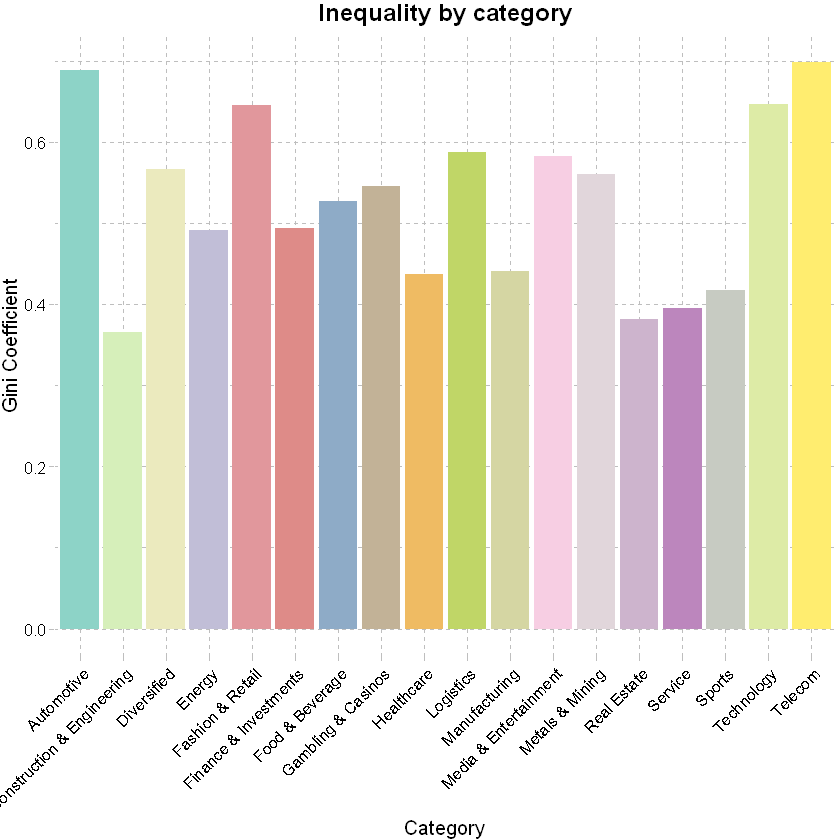

In [ ]:
# Creates plot with gini_by_industry dataset. aes, aethestic mapping, x and y axis, what to fill by
ggplot(gini_by_industry, aes(x = category, y = gini, fill = category)) +
  geom_bar(stat = "identity") + # Bar chart. Identity = bar height based on value in data for y. 
  scale_fill_manual( # Manual assignment of colors
    values = colorRampPalette(brewer.pal(12, "Set3"))(length(unique(gini_by_industry$category))) # Manual assignment of colors with a pallete to categories
  )+
  theme_pander() + # Theme from ggthemes
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), # Adjust x-axis text angle
    plot.title = element_text(hjust = 0.5)
    ) + # Adjust x-axis text angle and title position
    guides(fill = "none") + # Remove legend
  labs(
    title = "Inequality by category",
    x = "Category",
    y = "Gini Coefficient") # Add labels

# Conclusion
- After visualizing industries and their structural differences, example being industries with one major outlier vs multiple. And after statistically testing for those differences, i've found no singular industry is significantly different from one anothers wealth distribution.


- There are identifiable top performers in each industry. These top performers can likely represent the most successful companies in their industry, and they create a hierarchical structure since they account for a disproportinate share.


- Internal inequality is not always massive (Closer to 1, the more unequal, vice versa). This means despite every industry having outliers and being skewed, not all of those outliers are truly dominant.

- Practical direction I'd look for more data to learn about
    - This data does not test for influence or organization dynamics like best practices, or standards. However, top industries do tend to influence standards and practices. With more data, I could test this quantitatively.

In [ ]:
# Are any variables correlated with wealth?

# Select numeric columns
num_df <- df %>% select(where(is.numeric))

# Get predictor variable names
pred <- setdiff(names(x = num_df), "finalWorth")

# Calculate correlations with finalWorth
cor <- sapply(pred, function(var) {
    cor(num_df[[var]], num_df$finalWorth, use = "pairwise.complete.obs")
})

# Sort and display correlations
sort(abs(cor), decreasing = TRUE) %>% 
    kable()



|                                           |         x|
|:------------------------------------------|---------:|
|log_finalWorth                             | 0.7064322|
|rank                                       | 0.4489296|
|longitude_country                          | 0.1010477|
|age                                        | 0.0670528|
|birthYear                                  | 0.0667214|
|gross_tertiary_education_enrollment        | 0.0667107|
|birthDay                                   | 0.0593154|
|population_country                         | 0.0530242|
|cpi_country                                | 0.0428415|
|total_tax_rate_country                     | 0.0363806|
|cpi_change_country                         | 0.0357025|
|latitude_country                           | 0.0311221|
|life_expectancy_country                    | 0.0218189|
|tax_revenue_country_country                | 0.0092701|
|gross_primary_education_enrollment_country | 0.0088799|
|birthMonth                  

- No variable is strongly correlated with wealth
- log_finalWorth and rank are both roughly the same as wealth represented another way.